<a href="https://colab.research.google.com/github/Fabian-lewis/remote-work-productivity-analysis/blob/main/02_hypothesis_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
## Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
## Load Data From Colab
from google.colab import drive

drive.mount('/content/drive')

data_url = "/content/drive/MyDrive/RemoteWork"

## Load Cleaned data
try:
  df_2020 = pd.read_csv(f"{data_url}/cleaned_data_2020.csv")
  df_2021 = pd.read_csv(f"{data_url}/cleaned_data_2021.csv")

  print(f"2020 Data Loaded ✅ {df_2020.shape}")
  print(f"2021 Data Loaded ✅ {df_2021.shape}")

except Exception as e:
  print("Error Loading Data")
  print(e)

Mounted at /content/drive
2020 Data Loaded ✅ (1507, 74)
2021 Data Loaded ✅ (1507, 74)


/tmp/ipython-input-61126283.py:68: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("remote_intensity_group")["remote_productivity_vs_office"]
/tmp/ipython-input-61126283.py:68: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("remote_intensity_group")["remote_productivity_vs_office"]


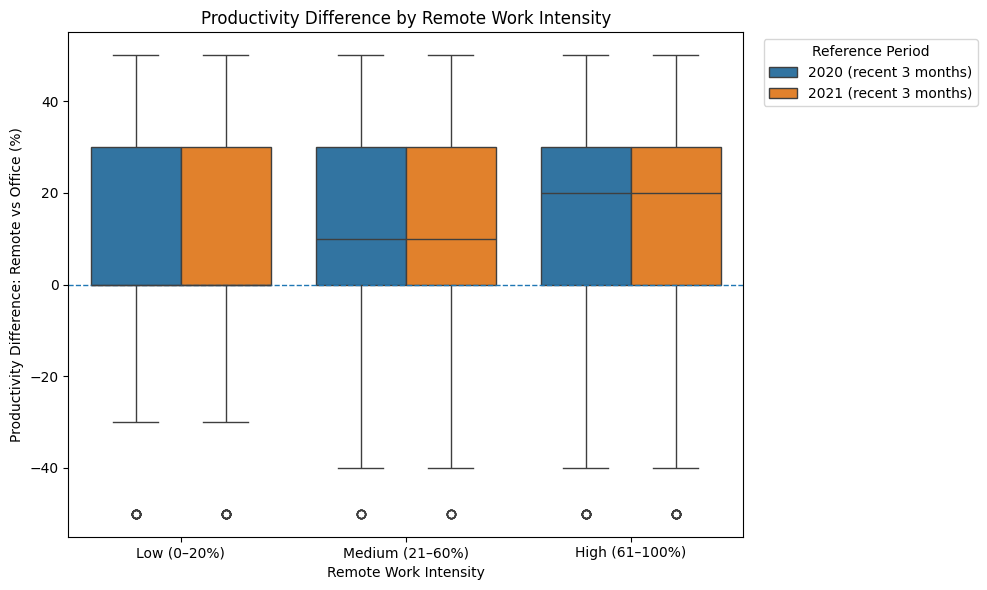

Group Summary 2020:

 --------------------------------------------------------------------------------
  remote_intensity_group  count       mean  median        std
0            Low (0–20%)    282   8.262411     0.0  24.973194
1        Medium (21–60%)    357  10.672269    10.0  23.716411
2         High (61–100%)    868  15.541475    20.0  23.269285

Group Summary 2021:

 --------------------------------------------------------------------------------
  remote_intensity_group  count       mean  median        std
0            Low (0–20%)    282   8.262411     0.0  24.973194
1        Medium (21–60%)    357  10.672269    10.0  23.716411
2         High (61–100%)    868  15.541475    20.0  23.269285



Hypothesis 1: Productivity Difference by Remote Work Intensity
2020 vs 2021
KruskalResult(statistic=np.float64(23.686480496083377), pvalue=np.float64(7.18697464025728e-06))


KruskalResult(statistic=np.float64(23.686480496083377), pvalue=np.float64(7.18697464025728e-06))


/tmp/ipython-input-61126283.py:113: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, g in df.groupby("remote_intensity_group")


In [ ]:
## Hypothesis 1
"""
H1 — Remote work intensity and productivity
H1: Employee productivity differs across levels of remote work intensity.

We are measuring:
Self-reported percentage difference in hourly productivity when remote vs on-site


Proxy variable:
remote_productivity_vs_office

caution ⚠️
This is:
Subjective
Comparative (remote vs office)
Perceived, not observed

"""

## Create remote intensity categories
def categorize_remote_share(series, scale="percent"):
    """
    Categorize remote work intensity into Low / Medium / High.

    Parameters:
    - series: pandas Series of remote share values
    - scale: 'percent' (0–100) or 'proportion' (0–1)

    Returns:
    - pandas Series of categorical labels
    """
    s = series.copy()

    if scale == "percent":
        s = s / 100

    return pd.cut(
        s,
        bins=[-np.inf, 0.20, 0.60, np.inf],
        labels=["Low (0–20%)", "Medium (21–60%)", "High (61–100%)"]
    )


## Apply to both datasets
df_2020["remote_intensity_group"] = categorize_remote_share(
    df_2020['remote_share_recent_actual'],
    scale="proportion"
)

df_2021["remote_intensity_group"] = categorize_remote_share(
    df_2021['remote_share_recent_actual'],
    scale="proportion"
)

## Keep only valid observations
analysis_df_2020 = df_2020.copy().dropna(
    subset=['remote_productivity_vs_office', 'remote_intensity_group']
)

analysis_df_2021 = df_2021.copy().dropna(
    subset=['remote_productivity_vs_office', 'remote_intensity_group']
)

## Exploratory group summary
def summarize_productivity(df):
    return (
        df.groupby("remote_intensity_group")["remote_productivity_vs_office"]
        .agg(count="count", mean="mean", median="median", std="std")
        .reset_index()
    )

group_summary_2020 = summarize_productivity(analysis_df_2020)
group_summary_2021 = summarize_productivity(analysis_df_2021)


## Visualize the results
combined_df = pd.concat([
    analysis_df_2020.assign(period="2020 (recent 3 months)"),
    analysis_df_2021.assign(period="2021 (recent 3 months)")
])

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=combined_df,
    x="remote_intensity_group",
    y="remote_productivity_vs_office",
    hue="period"
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Productivity Difference by Remote Work Intensity")
plt.xlabel("Remote Work Intensity")
plt.ylabel("Productivity Difference: Remote vs Office (%)")

plt.legend(
    title="Reference Period",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


## Hypothesis test (inference layer)
from scipy.stats import kruskal

def run_kruskal(df):
  groups = [
      g["remote_productivity_vs_office"].values
      for _, g in df.groupby("remote_intensity_group")
  ]
  return kruskal(*groups)

kruskal_result_2020 = run_kruskal(analysis_df_2020)
kruskal_result_2021 = run_kruskal(analysis_df_2021)

## Print the group summaries
print("Group Summary 2020:")
print("\n","-"*80)
print(group_summary_2020)

print("\nGroup Summary 2021:")
print("\n","-"*80)
print(group_summary_2021)

## Print the results
print("\n"*2)
print("="*80)
print("Hypothesis 1: Productivity Difference by Remote Work Intensity")
print("="*80)
print("2020 vs 2021")
print(kruskal_result_2020)
print("\n")
print(kruskal_result_2021)


### Summary Insight
---

    Employee productivity differs significantly across levels of remote work intensity.

    Employees with low levels of remote work report no productivity advantage when working remotely, while those in hybrid arrangements report approximately a 10% productivity gain
    
    Employees who are predominantly remote report the highest productivity gains, at approximately 20% relative to on-site work.

#### Evidence

1.   Statistical significance

    p ≈ 0.000007

    Kruskal–Wallis result (p < 0.001)

2.   Directional consistency

    In both survey periods,
    employees with medium to high remote intensity
    report higher median productivity compared to low-remote employees

  | Remote Intensity | Median Productivity Difference |
  | ---------------- | ------------------------------ |
  | Low (0–20%)      | **0%**                         |
  | Medium (21–60%)  | **+10%**                       |
  | High (61–100%)   | **+20%**                       |



---

#### ** Key Take-Away
1. High-remote workers may:

    - Have roles more suitable for remote work
    - Be more autonomous
    - Be more experienced

2. Median for low intensity = 0% (Not negative)

    This suggests:
    - Remote work is not harmful even at low intensity
    - But benefits only materialize with sufficient exposure

/tmp/ipython-input-4244382739.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("remote_intensity_group")["recommend_remote_recent"]
/tmp/ipython-input-4244382739.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("remote_intensity_group")["recommend_remote_recent"]
/tmp/ipython-input-4244382739.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, g in df.groupby("remote_intensity_group"




Hypothesis 2: Morale Difference by Remote Work Intensity
2020 vs 2021
KruskalResult(statistic=np.float64(178.62673161855494), pvalue=np.float64(1.628163703483464e-39))
--------------------------------------------------------------------------------
KruskalResult(statistic=np.float64(178.62673161855494), pvalue=np.float64(1.628163703483464e-39))





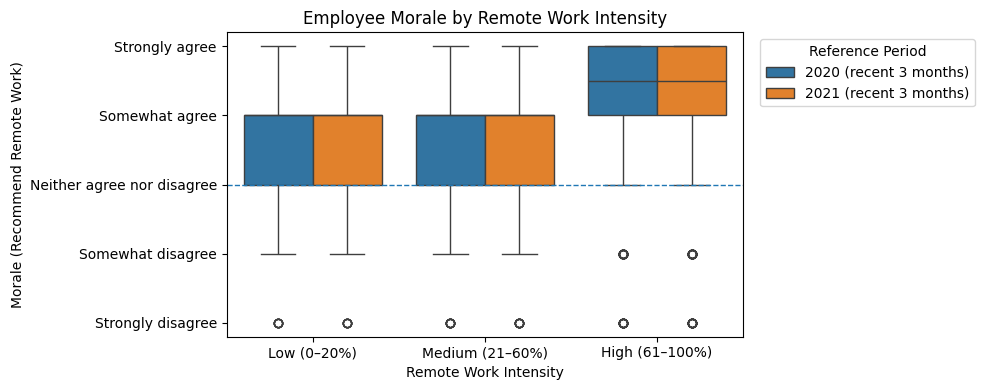

Group Summary 2020:

 --------------------------------------------------------------------------------
  remote_intensity_group  count  median      mean
0            Low (0–20%)    251     4.0  3.474104
1        Medium (21–60%)    357     4.0  3.789916
2         High (61–100%)    868     4.5  4.284562

Group Summary 2021:

 --------------------------------------------------------------------------------
  remote_intensity_group  count  median      mean
0            Low (0–20%)    251     4.0  3.474104
1        Medium (21–60%)    357     4.0  3.789916
2         High (61–100%)    868     4.5  4.284562


In [ ]:
## Hypothesis 2

"""
H2 — Remote work intensity and morale
H2: Employee morale differs across levels of remote work intensity.

Why this matters
Morale → retention → continuity → long-term productivity

Proxy Variable
recommend_remote_recent

Dataset features
remote_intensity_group
remote_share_recent_actual

"""
LIKERT_KEY = {
    1: "Strongly disagree",
    2: "Somewhat disagree",
    3: "Neither agree nor disagree",
    4: "Somewhat agree",
    5: "Strongly agree"
}

LIKERT_ORDER = list(LIKERT_KEY.values())

## Categorize the recent remote share into remote_intensity groups
## Use the datasets in H1 above (df_2020 and df_2021)

## Keep only valid observations
analysis_df_2020_morale = df_2020.copy().dropna(
    subset=['recommend_remote_recent', 'remote_intensity_group']
)

analysis_df_2021_morale = df_2021.copy().dropna(
    subset=['recommend_remote_recent', 'remote_intensity_group']
)

def summarize_morale(df):
  return (
      df.groupby("remote_intensity_group")["recommend_remote_recent"]
      .agg(
          count="count",
          median="median",
          mean="mean"
      )
      .reset_index()
  )

group_summary_2020_morale = summarize_morale(analysis_df_2020_morale)
group_summary_2021_morale = summarize_morale(analysis_df_2021_morale)


## Test Hypothesis
def kruskal_morale(df):
  groups = [
      g["recommend_remote_recent"].values
      for _, g in df.groupby("remote_intensity_group")
  ]
  return kruskal(*groups)

kw_morale_2020 = kruskal_morale(analysis_df_2020_morale)
kw_morale_2021 = kruskal_morale(analysis_df_2021_morale)

## Print the hypothesis test
print("\n"*2)
print("="*80)
print("Hypothesis 2: Morale Difference by Remote Work Intensity")
print("="*80)
print("2020 vs 2021")
print(kw_morale_2020)
print("-"*80)
print(kw_morale_2021)


## Visualize the results
combined_df = pd.concat([
    analysis_df_2020_morale.assign(period="2020 (recent 3 months)"),
    analysis_df_2021_morale.assign(period="2021 (recent 3 months)")
])

plt.figure(figsize=(10, 4))

sns.boxplot(
    data=combined_df,
    x="remote_intensity_group",
    y="recommend_remote_recent",
    hue="period"
)

plt.yticks(
    ticks=list(LIKERT_KEY.keys()),
    labels=list(LIKERT_KEY.values())
)

plt.axhline(3, linestyle="--", linewidth=1)
plt.title("Employee Morale by Remote Work Intensity")
plt.xlabel("Remote Work Intensity")
plt.ylabel("Morale (Recommend Remote Work)")
#plt.ylim(1, 5)

plt.legend(
    title="Reference Period",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
print("\n"*2)
plt.show()

## Print the group summaries
print("Group Summary 2020:")
print("\n","-"*80)
print(group_summary_2020_morale)

print("\nGroup Summary 2021:")
print("\n","-"*80)
print(group_summary_2021_morale)

In [ ]:
!pip install scikit-posthocs
import scikit_posthocs as sp
import pandas as pd


def dunn_posthoc(df, group_col, value_col, p_adjust="bonferroni"):
    return sp.posthoc_dunn(
        df,
        val_col=value_col,
        group_col=group_col,
        p_adjust=p_adjust
    )

dunn_2020 = dunn_posthoc(
    analysis_df_2020_morale,
    group_col="remote_intensity_group",
    value_col="recommend_remote_recent"
)

print("Dunn post-hoc test (2020):")
print(dunn_2020)


dunn_2021 = dunn_posthoc(
    analysis_df_2021_morale,
    group_col="remote_intensity_group",
    value_col="recommend_remote_recent"
)

print("\nDunn post-hoc test (2021):")
print(dunn_2021)


Dunn post-hoc test (2020):
                  Low (0–20%)  Medium (21–60%)  High (61–100%)
Low (0–20%)      1.000000e+00     8.464985e-04    2.141825e-32
Medium (21–60%)  8.464985e-04     1.000000e+00    2.512542e-18
High (61–100%)   2.141825e-32     2.512542e-18    1.000000e+00

Dunn post-hoc test (2021):
                  Low (0–20%)  Medium (21–60%)  High (61–100%)
Low (0–20%)      1.000000e+00     8.464985e-04    2.141825e-32
Medium (21–60%)  8.464985e-04     1.000000e+00    2.512542e-18
High (61–100%)   2.141825e-32     2.512542e-18    1.000000e+00


In [ ]:
def epsilon_squared(H, n, k):
    return (H - k + 1) / (n - k)


H_2020 = kw_morale_2020.statistic
n_2020 = analysis_df_2020_morale.shape[0]
k = analysis_df_2020_morale["remote_intensity_group"].nunique()

eps_2020 = epsilon_squared(H_2020, n_2020, k)

print(f"Epsilon-squared (2020): {eps_2020:.3f}")


H_2021 = kw_morale_2021.statistic
n_2021 = analysis_df_2021_morale.shape[0]

eps_2021 = epsilon_squared(H_2021, n_2021, k)

print(f"Epsilon-squared (2021): {eps_2021:.3f}")



Epsilon-squared (2020): 0.120
Epsilon-squared (2021): 0.120


### Summary Insight
    There is overwhelming statistical
    that employee morale differs
    across levels of remote work intensity.

---


#### Evidence
| Remote intensity | Median morale |
| ---------------- | ------------- |
| Low (0–20%)      | 4.0           |
| Medium (21–60%)  | 4.0           |
| High (61–100%)   | **4.5**       |

---
    This is a monotonic pattern:
    More remote exposure → higher morale endorsement

---
### Key Take-Away
    Regardless of when you measure it,
    higher remote exposure
    is associated with higher morale.




Hypothesis 3: Morale Difference by Alignment Gap Group
2020 vs 2021
KruskalResult(statistic=np.float64(47.73620311482659), pvalue=np.float64(4.3073999642177915e-11))
--------------------------------------------------------------------------------
KruskalResult(statistic=np.float64(47.73620311482659), pvalue=np.float64(4.3073999642177915e-11))





/tmp/ipython-input-313753312.py:80: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("alignment_gap_group")["recommend_remote_recent"]
/tmp/ipython-input-313753312.py:80: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("alignment_gap_group")["recommend_remote_recent"]
/tmp/ipython-input-313753312.py:92: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, g in df.groupby("alignment_gap_group")


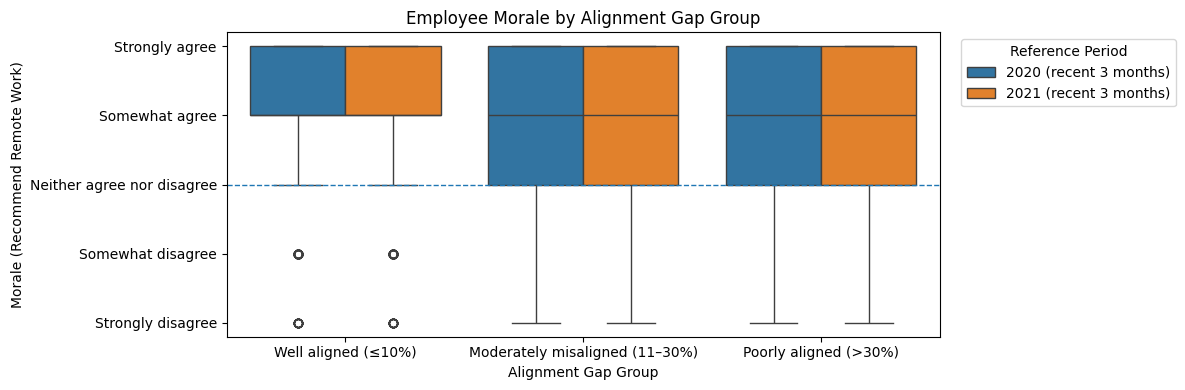

Group Summary 2020:

 --------------------------------------------------------------------------------
              alignment_gap_group  count      mean  median       std
0             Well aligned (≤10%)    918  4.159041     4.0  0.930977
1  Moderately misaligned (11–30%)    244  3.926230     4.0  0.948623
2           Poorly aligned (>30%)    314  3.719745     4.0  1.097976

Group Summary 2021:

 --------------------------------------------------------------------------------
              alignment_gap_group  count      mean  median       std
0             Well aligned (≤10%)    918  4.159041     4.0  0.930977
1  Moderately misaligned (11–30%)    244  3.926230     4.0  0.948623
2           Poorly aligned (>30%)    314  3.719745     4.0  1.097976


In [ ]:
## Hypothesis 3

"""
H3 — Preference alignment and morale
H3: Employees whose actual remote work share closely matches their preferred remote work share report higher morale than those with larger mismatches.

What we are measuring
Is morale driven by the amount of remote work, or by having one’s preference respected?

Dataset features
alignment_gap = |remote_share_recent_actual − remote_share_recent_preferred|

Morale Proxy
recommend_remote_recent

"""

### Step 1 Compute Alignment Gap

preference_analysis_df_2020 = df_2020.copy()
preference_analysis_df_2020["alignment_gap"] = (
    preference_analysis_df_2020["remote_share_recent_actual"] -
    preference_analysis_df_2020["remote_share_recent_preferred"]
).abs()

preference_analysis_df_2021 = df_2021.copy()
preference_analysis_df_2021["alignment_gap"] = (
    preference_analysis_df_2021["remote_share_recent_actual"] -
    preference_analysis_df_2021["remote_share_recent_preferred"]
).abs()


### Step 2 Create Alignment Categories
def categorize_alignment(series, scale="percent"):
    """
    Categorize alignment gap into Well Aligned / Moderately aligned / Poorly Aligned.

    Parameters:
    - series: pandas Series of alignment gap values
    - scale: 'percent' (0–100) or 'proportion' (0–1)

    Returns:
    - pandas Series of categorical labels
    """
    s = series.copy()

    if scale == "percent":
        s = s / 100

    return pd.cut(
        s,
        bins=[-np.inf, 0.10, 0.30, np.inf],
        labels=["Well aligned (≤10%)", "Moderately misaligned (11–30%)", "Poorly aligned (>30%)"]
    )

## Apply to both datasets
preference_analysis_df_2020["alignment_gap_group"] = categorize_alignment(
    preference_analysis_df_2020["alignment_gap"],
    scale="propotion"
)
preference_analysis_df_2021["alignment_gap_group"] = categorize_alignment(
    preference_analysis_df_2021["alignment_gap"],
    scale="propotion"
)


### Filter valid rows
preference_analysis_df_2020 = preference_analysis_df_2020.dropna(
    subset=["alignment_gap_group", "recommend_remote_recent"]
)

preference_analysis_df_2021 = preference_analysis_df_2021.dropna(
    subset=["alignment_gap_group", "recommend_remote_recent"]
)


## Exploratory group summary
def summarize_productivity(df):
    return (
        df.groupby("alignment_gap_group")["recommend_remote_recent"]
        .agg(count="count", mean="mean", median="median", std="std")
        .reset_index()
    )

group_summary_2020 = summarize_productivity(preference_analysis_df_2020)
group_summary_2021 = summarize_productivity(preference_analysis_df_2021)

## Test Hypothesis
def kruskal_morale(df):
  groups = [
      g["recommend_remote_recent"].values
      for _, g in df.groupby("alignment_gap_group")
  ]
  return kruskal(*groups)

kw_morale_2020 = kruskal_morale(preference_analysis_df_2020)
kw_morale_2021 = kruskal_morale(preference_analysis_df_2021)

## Print the hypothesis test
print("\n"*2)
print("="*80)
print("Hypothesis 3: Morale Difference by Alignment Gap Group")
print("="*80)
print("2020 vs 2021")
print(kw_morale_2020)
print("-"*80)
print(kw_morale_2021)


## Visualize the results
combined_df = pd.concat([
    preference_analysis_df_2020.assign(period="2020 (recent 3 months)"),
    preference_analysis_df_2021.assign(period="2021 (recent 3 months)")
])

plt.figure(figsize=(12, 4))

sns.boxplot(
    data=combined_df,
    x="alignment_gap_group",
    y="recommend_remote_recent",
    hue="period"
)

plt.yticks(
    ticks=list(LIKERT_KEY.keys()),
    labels=list(LIKERT_KEY.values())
)

plt.axhline(3, linestyle="--", linewidth=1)
plt.title("Employee Morale by Alignment Gap Group")
plt.xlabel("Alignment Gap Group")
plt.ylabel("Morale (Recommend Remote Work)")
#plt.ylim(1, 5)

plt.legend(
    title="Reference Period",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
print("\n"*2)
plt.show()

## Print the group summaries
print("Group Summary 2020:")
print("\n","-"*80)
print(group_summary_2020)

print("\nGroup Summary 2021:")
print("\n","-"*80)
print(group_summary_2020)


In [ ]:
### POST HOC TEXT
def dunn_posthoc(df, group_col, value_col, p_adjust="bonferroni"):
    return sp.posthoc_dunn(
        df,
        val_col=value_col,
        group_col=group_col,
        p_adjust=p_adjust
    )

dunn_2020 = dunn_posthoc(
    preference_analysis_df_2020,
    group_col="alignment_gap_group",
    value_col="recommend_remote_recent"
)

print("Dunn post-hoc test (2020):")
print("\n","-"*80)
print(dunn_2020)


dunn_2021 = dunn_posthoc(
    preference_analysis_df_2021,
    group_col="alignment_gap_group",
    value_col="recommend_remote_recent"
)

print("\nDunn post-hoc test (2021):")
print("\n","-"*80)
print(dunn_2021)

Dunn post-hoc test (2020):

 --------------------------------------------------------------------------------
                                Well aligned (≤10%)  \
Well aligned (≤10%)                    1.000000e+00   
Moderately misaligned (11–30%)         5.144984e-04   
Poorly aligned (>30%)                  2.255152e-10   

                                Moderately misaligned (11–30%)  \
Well aligned (≤10%)                                   0.000514   
Moderately misaligned (11–30%)                        1.000000   
Poorly aligned (>30%)                                 0.208284   

                                Poorly aligned (>30%)  
Well aligned (≤10%)                      2.255152e-10  
Moderately misaligned (11–30%)           2.082838e-01  
Poorly aligned (>30%)                    1.000000e+00  

Dunn post-hoc test (2021):

 --------------------------------------------------------------------------------
                                Well aligned (≤10%)  \
Well aligned (

### Summary Insight
The degree of misalignment matters, not just whether misalignment exists.



---


| Comparison                              | p-value      | Significant? |
| --------------------------------------- | ------------ | ------------ |
| Well aligned vs Moderately misaligned   | **0.00051**  | ✅ Yes        |
| Well aligned vs Poorly aligned          | **2.26e-10** | ✅ Yes        |
| Moderately misaligned vs Poorly aligned | **0.208**    | ❌ No         |


---

    Employees whose remote work matches their preference
    recommend remote work more strongly than those with moderate misalignment.

    Large misalignment is associated with substantially lower morale toward remote work.

    Once misalignment exceeds ~10%, additional misalignment
    does not significantly reduce morale further.



---
#### Key Take-Away
    Dunn’s post hoc tests revealed that well-aligned employees
    reported significantly higher remote work recommendation scores
    than both moderately and poorly aligned employees.
    However, no statistically significant difference was observed between moderately and poorly misaligned groups,
    suggesting a threshold effect whereby misalignment beyond a certain level does not further reduce morale.





Hypothesis 4: Productivity Difference by Alignment Gap Group
2020 vs 2021
KruskalResult(statistic=np.float64(42.30056848074617), pvalue=np.float64(6.524515447732484e-10))
--------------------------------------------------------------------------------
KruskalResult(statistic=np.float64(42.30056848074617), pvalue=np.float64(6.524515447732484e-10))





/tmp/ipython-input-179298340.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("alignment_gap_group")["remote_productivity_vs_office"]
/tmp/ipython-input-179298340.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("alignment_gap_group")["remote_productivity_vs_office"]
/tmp/ipython-input-179298340.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, g in df.groupby("alignment_gap_group"

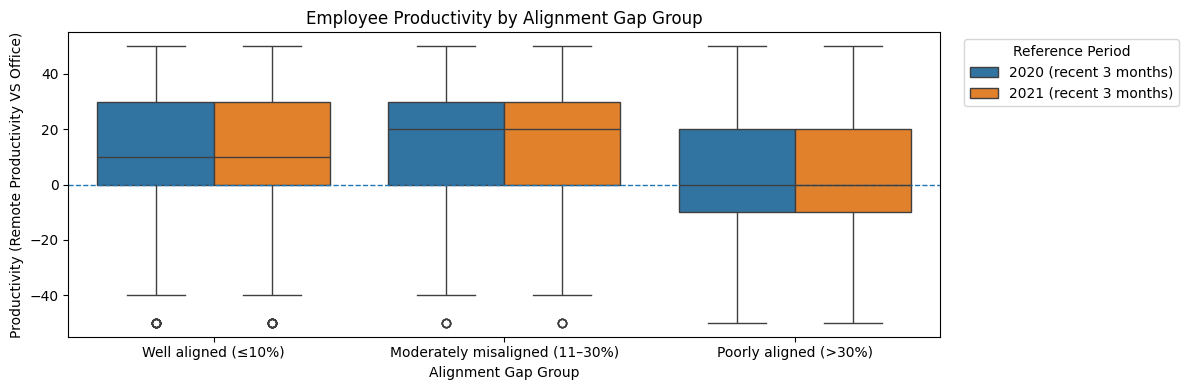

Group Summary 2020:

 --------------------------------------------------------------------------------
              alignment_gap_group  count       mean  median        std
0             Well aligned (≤10%)    918  15.729847    10.0  23.037142
1  Moderately misaligned (11–30%)    244  13.729508    20.0  23.227817
2           Poorly aligned (>30%)    314   5.254777     0.0  24.405364

Group Summary 2021:

 --------------------------------------------------------------------------------
              alignment_gap_group  count       mean  median        std
0             Well aligned (≤10%)    918  15.729847    10.0  23.037142
1  Moderately misaligned (11–30%)    244  13.729508    20.0  23.227817
2           Poorly aligned (>30%)    314   5.254777     0.0  24.405364


Dunn post-hoc test (2020):

 --------------------------------------------------------------------------------
                                Well aligned (≤10%)  \
Well aligned (≤10%)                    1.000000e+00   
Mod

In [ ]:
## Hypothesis 4

"""
H4 — Preference alignment and productivity
H4: Employees whose actual remote work share closely matches their preferred remote work share report higher productivity than those with larger mismatches.

What we are measuring
Is productivity driven by having one’s preference respected?

Dataset features
alignment_gap = |remote_share_recent_actual − remote_share_recent_preferred|

Morale Proxy
remote_productivity_vs_office

"""

## Step 1
"""
Compute Alignment Gap - We already did this in H3
"""

## Step 2
"""
Create alignment categories - We will use the same function in H3
"""

### Step 3 Filter valid rows
preference_analysis_df_2020 = preference_analysis_df_2020.dropna(
    subset=["alignment_gap_group", "remote_productivity_vs_office"]
)

preference_analysis_df_2021 = preference_analysis_df_2021.dropna(
    subset=["alignment_gap_group", "remote_productivity_vs_office"]
)


## Exploratory group summary
def summarize_productivity(df):
    return (
        df.groupby("alignment_gap_group")["remote_productivity_vs_office"]
        .agg(count="count", mean="mean", median="median", std="std")
        .reset_index()
    )

group_summary_2020 = summarize_productivity(preference_analysis_df_2020)
group_summary_2021 = summarize_productivity(preference_analysis_df_2021)

## Test Hypothesis
def kruskal_morale(df):
  groups = [
      g["remote_productivity_vs_office"].values
      for _, g in df.groupby("alignment_gap_group")
  ]
  return kruskal(*groups)

kw_morale_2020 = kruskal_morale(preference_analysis_df_2020)
kw_morale_2021 = kruskal_morale(preference_analysis_df_2021)

## Print the hypothesis test
print("\n"*2)
print("="*80)
print("Hypothesis 4: Productivity Difference by Alignment Gap Group")
print("="*80)
print("2020 vs 2021")
print(kw_morale_2020)
print("-"*80)
print(kw_morale_2021)


## Visualize the results
combined_df = pd.concat([
    preference_analysis_df_2020.assign(period="2020 (recent 3 months)"),
    preference_analysis_df_2021.assign(period="2021 (recent 3 months)")
])

plt.figure(figsize=(12, 4))

sns.boxplot(
    data=combined_df,
    x="alignment_gap_group",
    y="remote_productivity_vs_office",
    hue="period"
)

# plt.yticks(
#     ticks=list(LIKERT_KEY.keys()),
#     labels=list(LIKERT_KEY.values())
# )

plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Employee Productivity by Alignment Gap Group")
plt.xlabel("Alignment Gap Group")
plt.ylabel("Productivity (Remote Productivity VS Office)")
#plt.ylim(1, 5)

plt.legend(
    title="Reference Period",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
print("\n"*2)
plt.show()

## Print the group summaries
print("Group Summary 2020:")
print("\n","-"*80)
print(group_summary_2020)

print("\nGroup Summary 2021:")
print("\n","-"*80)
print(group_summary_2020)



### POST HOC TEXT
def dunn_posthoc(df, group_col, value_col, p_adjust="bonferroni"):
    return sp.posthoc_dunn(
        df,
        val_col=value_col,
        group_col=group_col,
        p_adjust=p_adjust
    )

dunn_2020 = dunn_posthoc(
    preference_analysis_df_2020,
    group_col="alignment_gap_group",
    value_col="remote_productivity_vs_office"
)

print("\n\nDunn post-hoc test (2020):")
print("\n","-"*80)
print(dunn_2020)


dunn_2021 = dunn_posthoc(
    preference_analysis_df_2021,
    group_col="alignment_gap_group",
    value_col="remote_productivity_vs_office"
)

print("\nDunn post-hoc test (2021):")
print("\n","-"*80)
print(dunn_2021)

In [ ]:
## Compute Cliffs_Delta
def cliffs_delta(x, y):
    """
    Compute Cliff's Delta effect size
    """
    nx = len(x)
    ny = len(y)

    gt = sum(ix > iy for ix in x for iy in y)
    lt = sum(ix < iy for ix in x for iy in y)

    return (gt - lt) / (nx * ny)


## Calculate Effect Size for H4
!pip install pingouin
import pingouin as pg

## Prepare and order Data

def prepare_data(df):
    df = df.copy()

    df = df.dropna(
        subset=["remote_productivity_vs_office", "alignment_gap_group"]
    )

    df["alignment_gap_group"] = pd.Categorical(
        df["alignment_gap_group"],
        categories=[
            "Well aligned (≤10%)",
            "Moderately misaligned (11–30%)",
            "Poorly aligned (>30%)"
        ],
        ordered=True
    )

    return df


df_2020 = prepare_data(preference_analysis_df_2020)
df_2021 = prepare_data(preference_analysis_df_2021)



## Compute Cliff's Delta Effect Size
def compute_effect_size(df):
    groups = df["alignment_gap_group"].cat.categories
    results = []

    for i in range(len(groups)):
        for j in range(i + 1, len(groups)):
            g1 = groups[i]
            g2 = groups[j]

            x = df.loc[df["alignment_gap_group"] == g1,
                       "remote_productivity_vs_office"].values
            y = df.loc[df["alignment_gap_group"] == g2,
                       "remote_productivity_vs_office"].values

            delta = cliffs_delta(x, y)

            results.append({
                "Group 1": g1,
                "Group 2": g2,
                "Cliff's delta": delta
            })

    return pd.DataFrame(results)



effect_sizes_2020 = compute_effect_size(df_2020)
effect_sizes_2021 = compute_effect_size(df_2021)

## Add Interpretation
def interpret_cliffs_delta(delta):
    abs_delta = abs(delta)
    if abs_delta < 0.147:
        return "Negligible"
    elif abs_delta < 0.33:
        return "Small"
    elif abs_delta < 0.474:
        return "Medium"
    else:
        return "Large"


effect_sizes_2020["Interpretation"] = (
    effect_sizes_2020["Cliff's delta"]
    .apply(interpret_cliffs_delta)
)

effect_sizes_2021["Interpretation"] = (
    effect_sizes_2021["Cliff's delta"]
    .apply(interpret_cliffs_delta)
)


## Print the results
print("Effect Sizes 2020:")
print("\n","-"*80)
print(effect_sizes_2020)

print("\nEffect Sizes 2021:")
print("\n","-"*80)
print(effect_sizes_2021)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 kB 6.6 MB/s eta 0:00:00
Effect Sizes 2020:

 --------------------------------------------------------------------------------
                          Group 1                         Group 2  \
0             Well aligned (≤10%)  Moderately misaligned (11–30%)   
1             Well aligned (≤10%)           Poorly aligned (>30%)   
2  Moderately misaligned (11–30%)           Poorly aligned (>30%)   

   Cliff's delta Interpretation  
0       0.043439     Negligible  
1       0.240005          Small  
2       0.201276          Small  

Effect Sizes 2021:

 --------------------------------------------------------------------------------
                          Group 1                         Group 2  \
0             Well aligned (≤10%)  Moderately misaligned (11–30%)   
1             Well aligned (≤10%)           Poorly aligned (>30%)   
2  Moderately misaligned (11–30%)           Poorly aligned (>30%)   

   Cliff's delta Interpre

### Summary Insight
In general

    Better alignment → higher perceived remote productivity




---

From the Dunn's Test we see

| Comparison                              | Adjusted p-value | Significant? |
| --------------------------------------- | ---------------- | ------------ |
| Well aligned vs Moderately misaligned   | **0.898**        | ❌ No         |
| Well aligned vs Poorly aligned          | **2.6e-10**      | ✅ Yes        |
| Moderately misaligned vs Poorly aligned | **0.00013**      | ✅ Yes        |


Poorly aligned workers are statistically less productive than Well aligned workers and Moderately misaligned workers

Well aligned and moderately misaligned workers do NOT differ significantly

This means:

    The productivity penalty only becomes statistically clear when alignment is very poor



---
Pairwise comparisons using Dunn’s post-hoc test revealed statistically significant differences in self-reported productivity between poorly aligned employees and both well-aligned and moderately misaligned employees (adjusted p < 0.001).

However, effect size analysis using Cliff’s delta indicated that these differences were small in magnitude (Δ = 0.24 and Δ = 0.20 respectively). The comparison between well-aligned and moderately misaligned groups showed a negligible effect size (Δ = 0.04) and was not statistically significant.

These findings suggest that while alignment gaps are associated with productivity differences, the practical impact is modest.


In [ ]:
### Hypothesis 5

"""
H5 — Organizational encouragement and productivity
H5: Higher levels of organizational encouragement and preparedness for remote work are associated with higher remote productivity.


Why we are testing this
To identify Whether organizations should actively invest in remote-work readiness

"""
from scipy.stats import spearmanr

def spearman_test(x, y, label_x, label_y):
    rho, p = spearmanr(x, y, nan_policy="omit")
    print(f"{label_x} vs {label_y}")
    print(f"  Spearman rho = {rho:.3f}")
    print(f"  p-value = {p:.4g}\n")
    return rho, p

print("-"*80)
print("2020 Dataset")
print("-"*80)
spearman_test(
    df_2020["org_encourage_remote_recent"],
    df_2020["remote_productivity_vs_office"],
    "Org encouragement (recent)",
    "Remote productivity"
)

spearman_test(
    df_2020["org_prepared_remote_recent"],
    df_2020["remote_productivity_vs_office"],
    "Org preparedness (recent)",
    "Remote productivity"
)


print("\n")
print("-"*80)
print("2021 Dataset")
print("-"*80)
spearman_test(
    df_2021["org_encourage_remote_recent"],
    df_2021["remote_productivity_vs_office"],
    "Org encouragement (recent)",
    "Remote productivity"
)

spearman_test(
    df_2021["org_prepared_remote_recent"],
    df_2021["remote_productivity_vs_office"],
    "Org preparedness (recent)",
    "Remote productivity"
)

--------------------------------------------------------------------------------
2020 Dataset
--------------------------------------------------------------------------------
Org encouragement (recent) vs Remote productivity
  Spearman rho = 0.052
  p-value = 0.0443

Org preparedness (recent) vs Remote productivity
  Spearman rho = 0.086
  p-value = 0.0009848



--------------------------------------------------------------------------------
2021 Dataset
--------------------------------------------------------------------------------
Org encouragement (recent) vs Remote productivity
  Spearman rho = 0.052
  p-value = 0.0443

Org preparedness (recent) vs Remote productivity
  Spearman rho = 0.086
  p-value = 0.0009848



(np.float64(0.08567606337603377), np.float64(0.0009847847145348588))

#### Working Insight
Organizational encouragement and preparedness for remote work are positively associated with remote productivity, but the relationships are weak, indicating that productivity is influenced by many factors beyond organizational support alone.


---
### Key Take- Away
Now that the overall direction of association is established, the goal is to identify which groups of workers rely more on organizational encouragement and preparedness for higher remote productivity.


In [ ]:
### H5 - Cont.. Function Definitions

"""
For which groups of workers does organizational encouragement and preparedness matter most for remote productivity?

Outcome: Remote productivity

Predictors:
  1. Organizational encouragement
  2. Organizational preparedness

Moderators / Subgroups:
  1. Remote work intensity
  2. Alignment gap
  3. Industry
  4. Managerial status
  5. Job tenure

"""

## Step 1: Define Variables
OUTCOME = "remote_productivity_vs_office"

PREDICTORS = [
    "org_encourage_remote_recent",
    "org_prepared_remote_recent"
]

## Step 2: Define Spearman Function
def spearman_effect(df, x, y, min_n=30):

  """
  Compute Spearman correlation with safeguards.

  Parameters
  ----------
  df : pd.DataFrame
  x : str (predictor)
  y : str (outcome)
  min_n : int (minimum sample size)

  Returns
  -------
  dict
  """

  sub = df[[x,y]].dropna()

  n = len(sub)

  if n < min_n:
    return {
        "Spearman_rho": np.nan,
        "p_value": np.nan,
        "n": n
    }

  rho, p = spearmanr(sub[x], sub[y])

  return {
      "Spearman_rho": rho,
      "p_value": p,
      "n": n
  }


## Step 3: Define the Sub-Group Analysis Engine

def subgroup_spearman_analysis(
    df,
    subgroup_col,
    predictors,
    outcome,
    min_n=30
):
  """
  Run Spearman correlations within subgroups.

  Parameters
  ----------
  df : pd.DataFrame
  subgroup_col : str
  predictors : list[str]
  outcome : str

  Returns
  -------
  pd.DataFrame
  """

  results = []

  for subgroup_value, group_df in df.groupby(subgroup_col):

    for predictor in predictors:
      stats = spearman_effect(
          group_df,
          x=predictor,
          y=outcome,
          min_n=min_n
      )

      results.append({
                "Subgroup_Type": subgroup_col,
                "Subgroup_Value": subgroup_value,
                "Predictor": predictor,
                "Spearman_rho": stats["Spearman_rho"],
                "p_value": stats["p_value"],
                "n": stats["n"]
            })

  return pd.DataFrame(results)

In [ ]:
### H5 Cont... Application

##
h5_df_2020 = df_2020.copy()
h5_df_2021 = df_2021.copy()

moderators = [
    "remote_intensity_group",
    "alignment_gap_group",
    "industry_broad",
    "is_manager",
    "job_tenure"
]

## Apply the functions for each moderator
for moderator in moderators:
  try:
    results_2020 = subgroup_spearman_analysis(
        h5_df_2020,
        subgroup_col=moderator,
        predictors=PREDICTORS,
        outcome=OUTCOME
    )

    results_2021 = subgroup_spearman_analysis(
        h5_df_2021,
        subgroup_col=moderator,
        predictors=PREDICTORS,
        outcome=OUTCOME
    )

    ## Print the Results
    print(f"\n\n2020 Results for {moderator}:")
    print("\n","-"*80)
    print(results_2020)

    print(f"\n\n2021 Results {moderator}:")
    print("\n","-"*80)
    print(results_2021)

  except Exception as e:
    print(f"An error occurred: {e}")




2020 Results for remote_intensity_group:

 --------------------------------------------------------------------------------
            Subgroup_Type   Subgroup_Value                    Predictor  \
0  remote_intensity_group      Low (0–20%)  org_encourage_remote_recent   
1  remote_intensity_group      Low (0–20%)   org_prepared_remote_recent   
2  remote_intensity_group  Medium (21–60%)  org_encourage_remote_recent   
3  remote_intensity_group  Medium (21–60%)   org_prepared_remote_recent   
4  remote_intensity_group   High (61–100%)  org_encourage_remote_recent   
5  remote_intensity_group   High (61–100%)   org_prepared_remote_recent   

   Spearman_rho   p_value    n  
0     -0.001672  0.978966  251  
1     -0.055324  0.382779  251  
2      0.029670  0.576328  357  
3      0.113601  0.031885  357  
4     -0.015459  0.649232  868  
5      0.059298  0.080802  868  


2021 Results remote_intensity_group:

 ----------------------------------------------------------------------------

/tmp/ipython-input-2290063681.py:93: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for subgroup_value, group_df in df.groupby(subgroup_col):
/tmp/ipython-input-2290063681.py:93: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for subgroup_value, group_df in df.groupby(subgroup_col):
/tmp/ipython-input-2290063681.py:93: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for subgroup_value, group_df in df.groupby(subgroup_col):
/

In [ ]:
## Subgroup 3: Industry

try:
  industry_results_2020 = apply_spearman_analysis(
      h5_df_2020,
      subgroup_col="industry_broad",
      predictors=PREDICTORS,
      outcome=OUTCOME
  )

  industry_results_2021 = apply_spearman_analysis(
      h5_df_2021,
      subgroup_col="industry_broad",
      predictors=PREDICTORS,
      outcome=OUTCOME
  )

  print("\n\n2020 Results: Where Spearman RHO > 0.2")
  print("\n", "-"*80)
  print(industry_results_2020[industry_results_2020['Spearman_rho'] > 0.2])

  print("\n\n2021 Results: Where Spearman RHO > 0.2")
  print("\n", "-"*80)
  print(industry_results_2021[industry_results_2021['Spearman_rho'] > 0.2])


except Exception as e:
  print(f"An error occurred: {e}")


#



2020 Results: Where Spearman RHO > 0.2

 --------------------------------------------------------------------------------
     Subgroup_Type                     Subgroup_Value  \
0   industry_broad    Accommodation and Food Services   
16  industry_broad  Health Care and Social Assistance   
24  industry_broad                     Other Services   
25  industry_broad                     Other Services   
34  industry_broad  Transport, Postal and Warehousing   

                      Predictor  Spearman_rho   p_value   n  
0   org_encourage_remote_recent      0.207671  0.262279  31  
16  org_encourage_remote_recent      0.230039  0.021987  99  
24  org_encourage_remote_recent      0.202345  0.058674  88  
25   org_prepared_remote_recent      0.228384  0.032341  88  
34  org_encourage_remote_recent      0.210115  0.127265  54  


2021 Results: Where Spearman RHO > 0.2

 --------------------------------------------------------------------------------
     Subgroup_Type                   